                   EVI      NDVI   LST_Day  LST_Night    Precip  dengue_cases
EVI           1.000000  0.782659  0.655005   0.179774  0.712387      0.241452
NDVI          0.782659  1.000000  0.237748   0.230180  0.317963      0.324761
LST_Day       0.655005  0.237748  1.000000   0.302635  0.663808      0.052059
LST_Night     0.179774  0.230180  0.302635   1.000000 -0.131293      0.271410
Precip        0.712387  0.317963  0.663808  -0.131293  1.000000      0.134208
dengue_cases  0.241452  0.324761  0.052059   0.271410  0.134208      1.000000


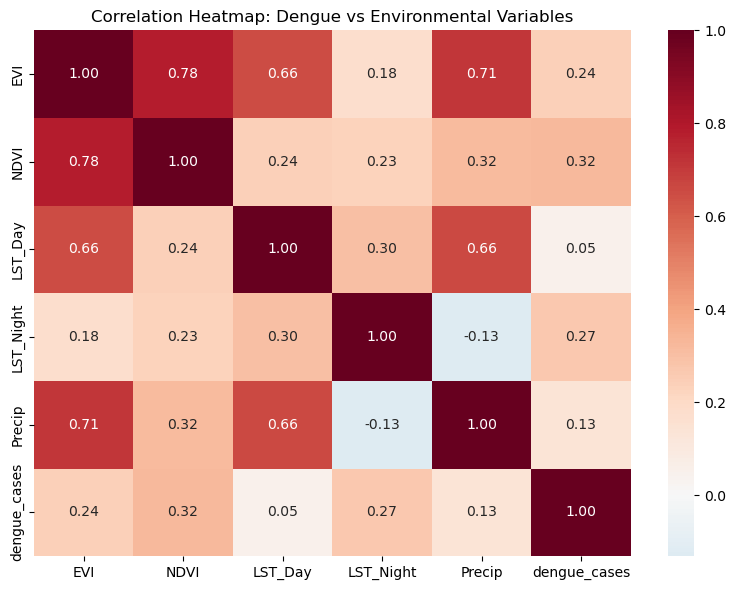

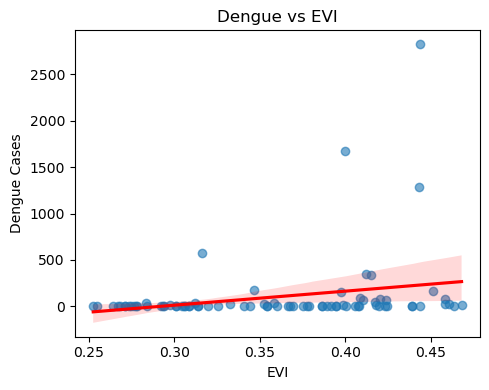

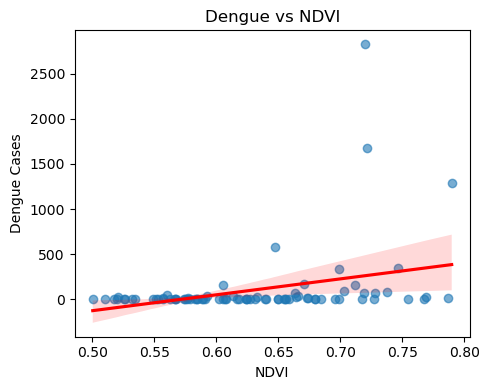

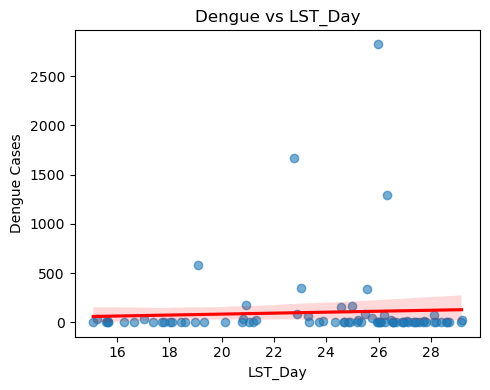

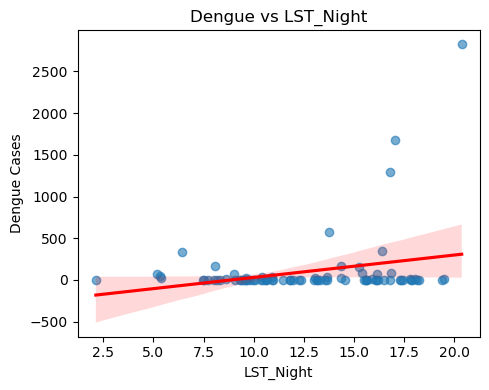

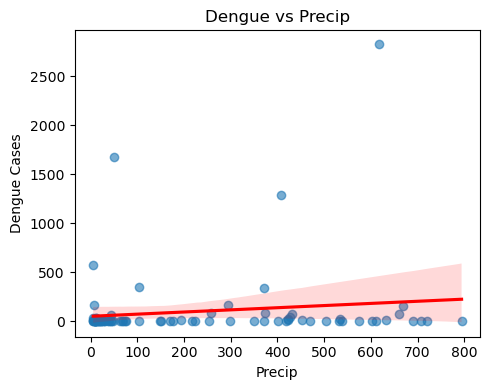

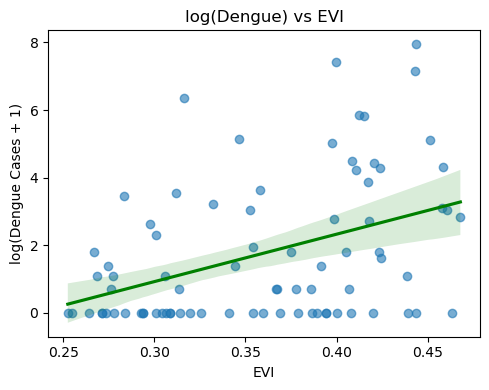

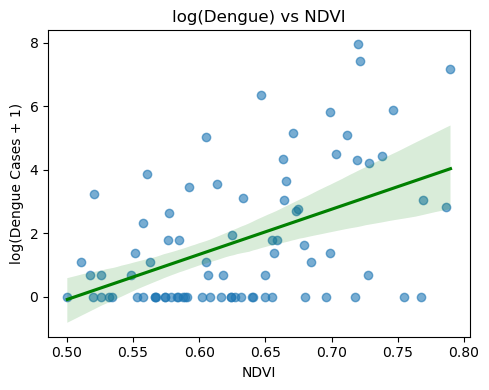

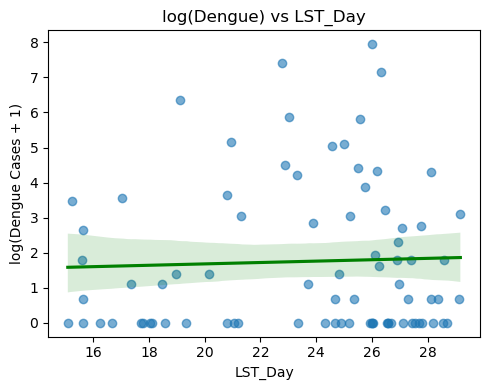

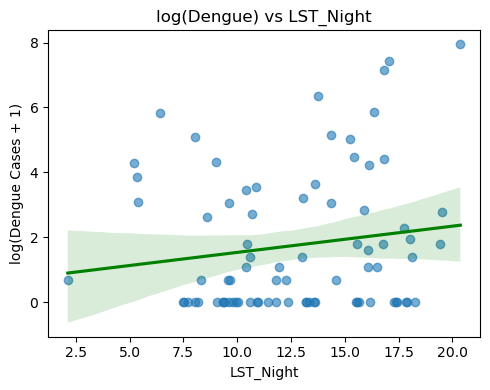

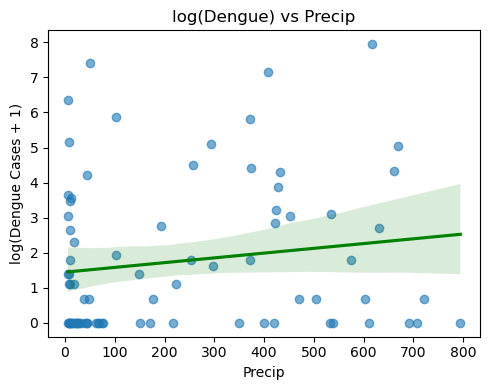

In [1]:
# ---------------------------------------------
# CORRELATION ANALYSIS: DENGUE vs ENV VARIABLES
# ---------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv(r"C:\Users\dhrub\Desktop\env_dengue_monthly_municipality.csv")

# -----------------------------
# 2. SELECT VARIABLES
# -----------------------------
env_vars = ["EVI", "NDVI", "LST_Day", "LST_Night", "Precip"]
target = "dengue_cases"

df_corr = df[env_vars + [target]]

# -----------------------------
# 3. CORRELATION MATRIX
# -----------------------------
corr_matrix = df_corr.corr(method="pearson")
print(corr_matrix)

# -----------------------------
# 4. HEATMAP
# -----------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)
plt.title("Correlation Heatmap: Dengue vs Environmental Variables")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. SCATTER PLOTS
# -----------------------------
for var in env_vars:
    plt.figure(figsize=(5, 4))
    sns.regplot(
        x=df[var],
        y=df[target],
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )
    plt.xlabel(var)
    plt.ylabel("Dengue Cases")
    plt.title(f"Dengue vs {var}")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6. LOG-TRANSFORM (OPTIONAL)
# -----------------------------
df["dengue_log"] = np.log1p(df["dengue_cases"])

for var in env_vars:
    plt.figure(figsize=(5, 4))
    sns.regplot(
        x=df[var],
        y=df["dengue_log"],
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "green"}
    )
    plt.xlabel(var)
    plt.ylabel("log(Dengue Cases + 1)")
    plt.title(f"log(Dengue) vs {var}")
    plt.tight_layout()
    plt.show()
